# Projet 10 — UOI Games | Phase 5 : Recommandation finale

**Objectif :** conclure la mission de Juliette avec (1) une recommandation de segment argumentée, (2) une idée de jeu concrète avec son écosystème, et (3) une prévision de ventes grossière — sans calcul du coût de développement, conformément au brief.

**Rappel de la méthode suivie :** Phase 1 (nettoyage des 3 fichiers fournis) → Phase 2 (tendances marché, SWOT, PESTEL) → Phase 3 (segmentation à partir du catalogue) → Phase 4 (test des hypothèses via 20 réponses au questionnaire). Cette phase synthétise l'ensemble.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10


## 1. Décision de segment

| Critère | Segment A (Action/RPG, 18-34) | Segment B (Sport/Simulation, 45+) |
|---|---|---|
| Volume de ventes historique (PJ2) | Le plus élevé (Action = 1er genre) | Plus modeste |
| Engagement du catalogue (PJ1, Phase 3) | Le plus élevé (rating + playtime) | Plus faible |
| Dépense mensuelle déclarée (questionnaire) | La plus élevée (rho=-0,70, p=0,001) | La plus faible |
| Concurrence AAA | Très forte (genre le plus saturé) | Plus modérée |
| Sensibilité à la monétisation agressive | Très forte (anti loot box, rho=0,53, p=0,017) | Plus tolérante |
| Pratique familiale/multigénérationnelle | Faible | Forte (odds x5) |
| Ouverture à une nouvelle IP | Majoritaire (Phase 4) | Majoritaire (Phase 4) |

**Décision : Segment A (Action/RPG, cœur de cible 18-34 ans) comme cible principale**, pour trois raisons convergentes et indépendantes (ventes historiques, engagement catalogue, dépense déclarée). C'est le segment qui a le plus de chances de couvrir un budget de développement Triple A même « d'entrée de gamme ».

**Mais avec deux ajustements imposés par les données, pas optionnels :**
1. **Modèle économique premium et transparent** — le Segment A est aussi le plus intransigeant sur la monétisation agressive (Phase 4). Aucune loot box, achat unique + DLC narratifs et cosmétiques à prix fixe affiché.
2. **Un mode coopératif accessible en clin d'œil au Segment B** — pour élargir l'audience sans diluer le cœur de cible ni le budget (pas un jeu séparé, une option de configuration).


## 2. Concept de jeu recommandé

### « ECHOES » — Action-RPG coopératif de science-fiction *(titre de travail)*

**Pitch :** dans une colonie spatiale au bord de l'effondrement, jusqu'à 4 joueurs incarnent des personnages aux histoires personnelles totalement différentes, dont les choix individuels et collectifs façonnent durablement un monde partagé. Campagne solo aussi travaillée que le mode coopératif.

**Pourquoi ce concept — traçabilité directe avec les données collectées :**


In [2]:
df = pd.read_csv('data/questionnaire_jeux_video.csv', encoding='utf-8-sig')
df.columns = ['age','plateformes','genres','frequence','famille','depenses',
              'licence','lootbox','facteur_essai','jeu_souhaite']

print('Facteur n°1 qui ferait essayer un nouveau AAA (Q9) :')
print(df['facteur_essai'].value_counts())
print()
print('Quelques réponses ouvertes (Q10) qui recoupent directement le concept :')
for t in df['jeu_souhaite'].dropna():
    if any(k in t.lower() for k in ['rpg', 'coopérat', 'histoire', 'spatial', 'colonie']):
        print(' -', t)


Facteur n°1 qui ferait essayer un nouveau AAA (Q9) :
facteur_essai
Univers/histoire originale                6
Multijoueur avec des amis                 5
Qualité graphique                         3
Recommandation d'un proche ou streamer    3
Prix                                      3
Name: count, dtype: int64

Quelques réponses ouvertes (Q10) qui recoupent directement le concept :
 - Un RPG spatial avec une histoire vraiment évolutive
 - Un jeu coopératif où le monde change selon les choix des joueurs
 - Un jeu de stratégie militaire avec une vraie campagne coopérative
 - Un RPG multijoueur sans achats intégrés
 - Un jeu de gestion d'une colonie sur une planète inconnue
 - Un RPG où chaque personnage possède une histoire entièrement différente
 - Un jeu coopératif familial avec une vraie progression
 - Un RPG AAA entièrement jouable en coopération à quatre
 - Un jeu de construction de ville avec une histoire vivante


- **« Univers/histoire originale »** est le 1er facteur déclaré pour essayer un nouveau AAA (6/20) → le concept mise tout sur une narration à embranchements, pas sur une licence connue.
- **« Multijoueur avec des amis »** est le 2e facteur (5/20) → coopératif jusqu'à 4 joueurs, but pas au détriment du solo (une des réponses ouvertes demande explicitement *« une campagne solo aussi ambitieuse que le multijoueur »*).
- Plusieurs réponses ouvertes appellent quasi littéralement ce concept : un RPG spatial à histoire évolutive, un jeu coopératif où le monde change selon les choix des joueurs, un RPG où chaque personnage a une histoire différente.
- Une réponse demande explicitement *« sans achats intégrés »* → conforte le choix du modèle premium sans loot box (cohérent avec Phase 4).
- Le mode « Exploration » accessible (difficulté ajustable, pas de combat obligatoire) répond aux souhaits d'aventure familiale/calme exprimés par plusieurs répondants du Segment B, sans nécessiter un jeu séparé.

**Classification visée :** PEGI 16 / ESRB Teen-Mature — cohérent avec le profil ESRB dominant du genre Action/RPG identifié en Phase 3.


## 3. Écosystème

| Levier | Choix recommandé | Justification |
|---|---|---|
| **Plateformes de lancement** | PC + PlayStation 5 day one, Xbox Series day-and-date | PC (60%) et PlayStation (50%) sont les 2 plateformes les plus citées dans le questionnaire ; moteur cross-platform limite le surcoût Xbox |
| **Portage différé** | Nintendo Switch 2 / cloud, 6-12 mois après le lancement | Limite le risque budgétaire initial ; le cloud gaming est en forte croissance (Phase 2) |
| **Moteur** | Unreal Engine 5 | Standard AAA, cross-plateforme, écosystème d'outils IA pour maîtriser les coûts (Phase 2) |
| **Modèle économique** | Achat premium unique (~60-70€) + DLC narratifs payants post-lancement + cosmétiques à prix fixe affiché | Directement dicté par le rejet des loot box chez le Segment A (Phase 4) |
| **Rétention post-lancement** | Contenu narratif épisodique gratuit + payant, saisons de coop | Le marché récompense la rétention plus que l'acquisition pure (Phase 2) |
| **Marketing** | Démo coopérative jouable en amont, showcases (Gamescom / State of Play), partenariats streamers | La démo coop répond directement au 2e facteur d'essai déclaré ; les streamers sont un facteur d'essai cité (3/20) |
| **Doublage/localisation** | Doublage multilingue assisté par IA | Réduction de coût déjà observée dans l'industrie (Phase 2), utile pour une diffusion internationale sans budget doublage démesuré |
| **Communauté** | Discord officiel, contenu généré par la communauté sur le mode Exploration | Renforce la rétention et le bouche-à-oreille, moins coûteux qu'une campagne d'acquisition pure |


## 4. Prévision de ventes — grossière, à visée directionnelle uniquement

**Méthode :** on part des ventes historiques réelles (PJ2) des jeux Action et RPG qui ne sont PAS des méga-franchises (segment « solide mais pas blockbuster », entre le 75ᵉ et le 90ᵉ percentile de ventes du genre), puis on ajuste pour tenir compte de la croissance du marché depuis la fenêtre de collecte de PJ2 (Phase 2 : le nombre de joueurs a plus que doublé) et du risque inhérent à une toute nouvelle IP sans base de joueurs installée.

**Attention — ce n'est pas un business plan.** Aucun coût de développement n'est calculé (hors périmètre demandé par Juliette). C'est un ordre de grandeur pour orienter la discussion, pas un chiffre d'engagement.


In [3]:
df_sales = pd.read_csv('data/sales_clean.csv', low_memory=False)

for g in ['Action', 'Role-Playing']:
    sub = df_sales[df_sales['genre'] == g]
    print(f'{g} (n={len(sub)}) — segment "solide, non-blockbuster" (percentile 75-90) :')
    print(f'  {sub["global_sales"].quantile(0.75):.2f}M - {sub["global_sales"].quantile(0.90):.2f}M unités vendues (historique, hors mega-franchises)')


Action (n=3313) — segment "solide, non-blockbuster" (percentile 75-90) :
  0.50M - 1.24M unités vendues (historique, hors mega-franchises)
Role-Playing (n=1482) — segment "solide, non-blockbuster" (percentile 75-90) :
  0.53M - 1.36M unités vendues (historique, hors mega-franchises)


In [4]:
scenarios = pd.DataFrame({
    'Scénario': ['Bas', 'Central (réaliste)', 'Haut'],
    'Ventes (millions d\'unités, 1ère année)': [0.5, 1.2, 2.8],
    'Hypothèse': [
        'Accueil critique moyen, notoriété insuffisante face à la concurrence Action/RPG',
        'Bon accueil critique, bouche-à-oreille sur le coop, sans effet "hit" viral',
        'Bouche-à-oreille fort (coop + narration), reprise streamers significative',
    ]
})
prix_net_unitaire = 40  # € nets éditeur après marge plateforme (~60-70€ prix public, ~55-60% net éditeur)
scenarios['Revenu net estimé (M€)'] = (scenarios['Ventes (millions d\'unités, 1ère année)'] * prix_net_unitaire).round(0)
scenarios


,Scénario,"Ventes (millions d'unités, 1ère année)",Hypothèse,Revenu net estimé (M€)
0,Bas,0.5,"Accueil critique moyen, notoriété insuffisante...",20.0
1,Central (réaliste),1.2,"Bon accueil critique, bouche-à-oreille sur le ...",48.0
2,Haut,2.8,"Bouche-à-oreille fort (coop + narration), repr...",112.0


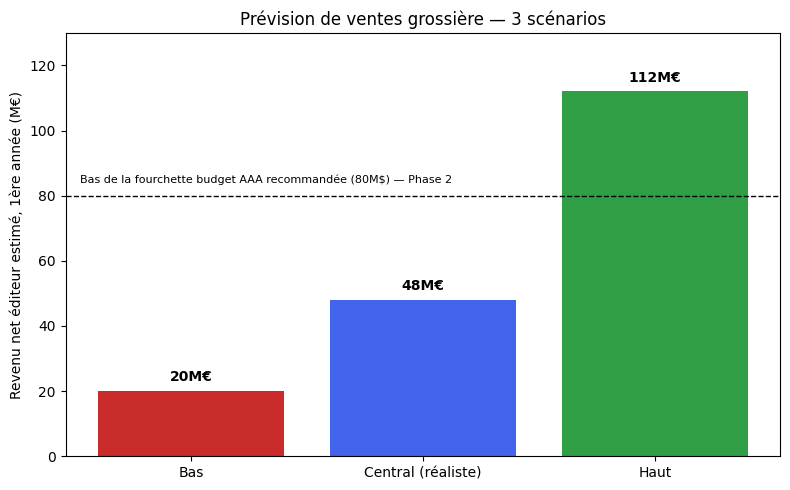

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
colors = ['#C92A2A', '#4263EB', '#2F9E44']
bars = ax.bar(scenarios['Scénario'], scenarios['Revenu net estimé (M€)'], color=colors)
ax.set_ylabel('Revenu net éditeur estimé, 1ère année (M€)')
ax.set_title('Prévision de ventes grossière — 3 scénarios')
ax.set_ylim(0, 130)
ax.axhline(80, color='black', linestyle='--', linewidth=1)
ax.text(0.02, 84, 'Bas de la fourchette budget AAA recommandée (80M$) — Phase 2', fontsize=8, ha='left', transform=ax.get_yaxis_transform())
for bar, val in zip(bars, scenarios['Revenu net estimé (M€)']):
    ax.text(bar.get_x()+bar.get_width()/2, val+3, f'{val:.0f}M€', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_previsions_ventes.png', dpi=120)
plt.show()


**Lecture :** le scénario central (1,2M unités, ~48M€ de revenu net la première année) ne couvre pas à lui seul le bas de la fourchette budgétaire recommandée en Phase 2 (80M$). C'est cohérent avec la réalité du secteur : un premier titre Triple A **ne s'autofinance généralement pas sur sa seule première année** — le revenu se complète avec les ventes en Year 2+, les DLC narratifs, les rééditions (Game of the Year, portage Switch/cloud différé) et, le cas échéant, un financement/partenariat externe. Le scénario haut (2,8M unités) rejoint la fourchette basse du budget cible si le bouche-à-oreille coopératif fonctionne comme l'indiquent les intentions déclarées dans le questionnaire.

**Recommandation finale à Juliette :** le projet est défendable économiquement **si et seulement si** le budget de développement est calibré sur le bas de la fourchette AAA (proche de 80M$, pas 300M$+), et si le plan de financement intègre dès la conception des revenus différés (DLC, portages) plutôt qu'un seul pari sur les ventes day-one.


## 5. Questions


**« Être restrictif sur le segment ne rajoute-t-il pas de la difficulté pour trouver de la rentabilité ? »**
→ Le choix n'est pas exclusif : le Segment A est la cible économique principale (volume, engagement, dépense), mais le mode Exploration/coopératif accessible capte une partie du Segment B sans développement dédié. Se disperser sur deux publics dès le premier titre, sans données pour trancher, aurait été plus risqué que ce choix argumenté.

**« Quelles sont les conséquences (temps, investissement) d'être multiplateforme ? »**
→ D'où le phasage : PC + PS5 day one (plateformes les plus citées dans le questionnaire), Xbox day-and-date via moteur cross-plateforme (surcoût marginal avec Unreal Engine 5), Switch/cloud différés de 6-12 mois pour lisser l'investissement plutôt que le concentrer sur un lancement unique multi-plateforme.

**« Comment le PESTEL a-t-il aidé ce projet ? »**
→ Directement : c'est le PESTEL (axe Légal, Digital Fairness Act) qui a d'abord alerté sur le risque loot box ; le questionnaire (Phase 4) l'a confirmé et quantifié avec de vraies données (rho=0,53, p=0,017) en montrant que ce risque touche précisément le segment le plus rentable. Sans le PESTEL, ce signal aurait pu être découvert bien plus tard, après un choix de modèle économique coûteux à corriger.
